# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [1]:
# importar librerías
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [3]:
# mostrar las primeras 5 filas de plans
plans.head(5)

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [4]:
# mostrar las primeras 5 filas de users
users.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [5]:
# mostrar las primeras 5 filas de usage
usage.head(5)

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [6]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [7]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [8]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [9]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [10]:
# cantidad de nulos para users
print("Usuarios nulos :")
print(users.isna().sum())
print("Proporción:")
print(users.isna().mean())

Usuarios nulos :
user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
Proporción:
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [11]:
# cantidad de nulos para usage
print("Usuarios nulos :")
print(usage.isna().sum())
print("Proporción:")
print(usage.isna().mean())


Usuarios nulos :
id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
Proporción:
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica brevemente tus decisiones (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?  
- Indica qué harías: ¿imputar, eliminar, ignorar?

**city:** tiene un 11.72% por lo que se investigará para decidir si se imputará o será ignorado.
  
**churn_date:** tiene un valor alto del 88.35% y será ignorado ya que corresponde a la fecha de cancelación de la suscripción y es esperado que el valor sea nulo si está vigente.

**date** tiene un porcentaje muy bajo, apenas el 0.12% por lo que será imputado con el valor del registro adyacente.

**duration** es del 55.19% y es un valor crítico para el análisis, por lo que requiere investigación para determinar si es conveniente 
imputar o dejar como nulos. No serán eliminados. 

**length** con un 44% también es un dato valioso para el análisis, por lo que es importante su revisión para decidir su imputación. No será eliminado.

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [12]:
# explorar columnas numéricas de users
display(users.describe())

#Total de sentiels -999
conteo = (users['age'] == -999).sum()
print(f"Cantidad de errores: {conteo}")

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


Cantidad de errores: 55


- La columna `user_id` no tiene valores faltantes y todos son únicos.
- La columna `age' no tiene valores faltantes, pero el valor mínimo es inválido ya que es negativo y es un sentinel. 

In [13]:
# explorar columnas numéricas de usage
usage.describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- Las columnas `id` y `user_id` no tienen valores nulos, todos los registros están asociados a un usuario. Ambas son keys.
- La columna `duration`:
  
   Tiene solo 17,924 registros de un total de 40,000,  más del 55% de los datos son nulos.
   Su promedio es 5.20, pero la mediana es 3.50
   El valor máximo es 120, lo cual es muy lejano al promedio de 5.
   Tenemos un sesgo a la derecha

- La columna `length` :

   Tiene 22,104 registros también con más del 45% de datos nulos.
  
   El promedio es 52.12 y el tercer cuartil (75%) es 64, pero el valor máximo es 1490 y es muy alto.

   La desviación estándar es de 56.61,que es incluso mayor que el promedio, lo que indica una gran dispersión de los datos.
  
   El valor mínimo en ambas columnas es cero y no tendría sentido una llamada con cero duración. 
 

In [14]:
# explorar columnas categóricas de users 
columnas_user = ['city', 'plan']
display(users[columnas_user].describe())

# Imprime el conteo de valores "?" en la columna city
print("Cantidad de valores '?' en 'city'", users['city'].isin(['?']).sum())
print("Cantidad de valores '?' en 'plan'", users['plan'].isin(['?']).sum())

,city,plan
count,3531,4000
unique,7,2
top,Bogotá,Basico
freq,808,2595


Cantidad de valores '?' en 'city' 96
Cantidad de valores '?' en 'plan' 0


- La columna `city` tiene 7 categorías, Bogotá es  la más común con una frecuencia de 808 sin embargo, hay datos faltantes.
- La columna `plan` tiene 2 categorías, siendo el plan Básico el más fecuente con el 64.87%

In [15]:
# explorar columna categórica de usage
display(usage['type'].describe())
print("Cantidad de valores '?' en 'type':", users['plan'].isin(['?']).sum())

count     40000
unique        2
top        text
freq      22092
Name: type, dtype: object

Cantidad de valores '?' en 'type': 0


- La columna `type` es una columna de tipo objeto, no hay datos faltantes. Solo hay 2 valores posibles  call y text,  siendo este último el más frecuente. No hay sentinels en esta columna.


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?  
- ¿Qué acción tomarías?

**age** tiene sentiles

Acciones a tomar:
1. Estandarizar sentinels reemplazandolos por NaN
2. Crear  flag para dejar marcado el cambio
3. Imputar valores ausentes utilizando la mediana de la edad.


**duration** y **length** tenemos valores nulos  y outliers lo que genera un sesgo a la derecha.

Acciones a tomar:
1. Determina si los nulos son "Missing at Random" o si representan eventos que no ocurrieron.
2. Debido al alto volumen de nulos, la eliminación nos dejaría con pocos datos, por lo que consideraré la imputación mediante la mediana.
3. Considerando que 1490 es un valor físicamente imposible, voy a winsorizar. Es decir, limitar los valores extremos al percentil 99 para reducir el ruido estadístico sin eliminar la fila completa.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [16]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')

In [17]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(users['reg_date'], errors='coerce')

In [18]:
# Revisar los años presentes en `reg_date` de users
users['reg_date'].dt.year.unique()


array([2022, 2026, 2023, 2024])

In [19]:
# Esto te mostrará todas las columnas de los usuarios registrados en 2026
registros_2026 = users[users['reg_date'].dt.year == 2026]
registros_2026.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
40,10040,Ana,Garcia,59,Medellín,2026-05-10,Basico,NaN
56,10056,Luis,Garcia,29,CDMX,2026-05-10,Basico,"1,72187E+18"
60,10060,Carlos,Torres,45,CDMX,2026-05-10,Basico,NaN
70,10070,Mariana,Gomez,50,CDMX,2026-05-10,Premium,NaN
248,10248,Sofia,Garcia,20,Medellín,2026-05-10,Premium,"1,72506E+18"


En `reg_date`, hay datos correspondientes a 2026 cuando el dataset solo debería tener datos hasta 2024.

In [20]:
# Revisar los años presentes en `date` de usage
usage['date'].dt.year.unique()

array([2022., 2026., 2023., 2024.,   nan])

En `date`, hay fechas nulas, el formato no es el adecuado, no deberían haber datos del 2026 cuando una condición es que solo se tenga registro haste el 2024. 
Basaremos el análisis en estas fechas.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- ¿Qué harías con ellas?

1. Filtrar el dataset para que solo haya registros del 2024
2. Cambiar 'date' a tipo fecha
4. Los nulos en date, aunque son solo 50 registros, para no perderlos se imputarán con el valor del registro adyacente utilizando Forward Fill. y los valores mayores a 2024 se convertirán en NAt.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [21]:
# Reemplazar -999 por la mediana de age
age_mediana = users['age'].median()
users['age'] = users['age'].replace(-999, age_mediana)
# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.122250
std        17.690408
min        18.000000
25%        33.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [22]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', pd.NA)
# Verificar cambios
print("Cantidad de valores '?' en 'city'=", users['city'].isin(['?']).sum())

Cantidad de valores '?' en 'city'= 0


In [23]:
# Marcar fechas futuras como NA para reg_date
import numpy as np

#verificamos que reg_date sea de tipo fecha 
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')

# Si el año es mayor a 2024, pon NaT, de lo contrario deja la fecha original
users['reg_date'] = np.where(users['reg_date'].dt.year<= 2024, users['reg_date'], pd.NaT)

# Verificar cambios
users['reg_date'] = pd.to_datetime(users['reg_date'])
nulos_futuros = users['reg_date'].isna().sum()
print(f"Se marcaron {nulos_futuros} fechas futuras como NaT.")
print(f"Registros después de 2024: {(users['reg_date'].dt.year > 2024).sum()}")


Se marcaron 40 fechas futuras como NaT.
Registros después de 2024: 0


### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [24]:
# Verificación MAR en usage (Missing At Random) para duration

#Verificación agrupado con type
print("Verificación MAR  para duration agrupado con type")
print()
display(usage['duration'].isna().groupby(usage['type']).mean().sort_values(ascending=False))

print()
#Unimos dataframes para tener 'city' y 'duration' juntas
df_analisis = pd.merge(usage, users, on='user_id', how='left')

#Verificación agrupado por type
print("Verificación MAR  para duration agrupado con city")
df_analisis['duration'].isna().groupby(df_analisis['city']).mean().sort_values(ascending=False)


Verificación MAR  para duration agrupado con type



type
text    0.999276
call    0.000000
Name: duration, dtype: float64


Verificación MAR  para duration agrupado con city


city
CDMX        0.557803
Bogotá      0.555501
Cali        0.550847
GDL         0.547911
Medellín    0.546567
MTY         0.542737
Name: duration, dtype: float64

In [25]:
# Verificación MAR en usage (Missing At Random) para length
#Verificación agrupado con type
print("Verificación MAR  para duration agrupado con type")
print()
display(usage['length'].isna().groupby(usage['type']).mean().sort_values(ascending=False))

#Verificación agrupado por city
print("Verificación MAR  para duration agrupado con city")
display(df_analisis['length'].isna().groupby(df_analisis['city']).mean().sort_values(ascending=False))






Verificación MAR  para duration agrupado con type



type
call    0.99933
text    0.00000
Name: length, dtype: float64

Verificación MAR  para duration agrupado con city


city
MTY         0.455781
Medellín    0.453107
GDL         0.451408
Cali        0.447976
Bogotá      0.443764
CDMX        0.441651
Name: length, dtype: float64

Haz doble clic aquí y escribe que tu diagnóstico de nulos en `duration` y `length`

**Resultado**

Al agrupar `duration`  y `length` por ciudad, se observa que no hay una ciudad con valores vacíos especialmente altos, por lo que la falta de información no está asociada a este dato. Sin embargo, al filtrar por tipo, se observa que la ausencia no es aleatoria. El 99% de los registros nulos están asociados a type = call (llamada) indicando que el fallo o falta de captura es exclusivo en esta interacción.  Comprobándose que los datos faltantes son de tipo  <u> Missing At Random</u> (MAR)*.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`
-  `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [26]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas
usage["total_min"] = usage["duration"].fillna(0) #conocer el total en minutos

# Agrupar información por usuario
# Agrupamos por 'user_id' y calculamos la media de 'duration'

usage_agg = usage.groupby('user_id').agg({
    'is_text': 'sum',
    'is_call': 'sum', 
    'total_min': 'sum'
 })       .reset_index()

# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,total_min
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [27]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={
    'is_text': 'cant_mensajes',
    'is_call': 'cant_llamadas',
    'total_min': 'cant_minutos_llamada'
})
# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [28]:
# Combinar la tabla agregada con el dataset de usuarios

user_profile = pd.merge(usage_agg, users, on='user_id', how='left')

user_profile.head(5)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,7,3,23.70,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,5,10,33.18,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,5,2,10.74,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,11,3,8.99,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,4,3,8.01,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [29]:
# Resumen estadístico de las columnas numéricas

user_profile['reg_date'] = pd.to_datetime(user_profile['reg_date'], errors='coerce')  
resultado = user_profile[(user_profile['reg_date'].dt.year==2024)]

resultado.describe()

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada,age
count,1330.000000,1330.000000,1330.000000,1330.000000,1330.000000
mean,13332.699248,5.500000,4.557143,24.126669,48.414286
std,384.969999,2.382293,2.140329,19.458620,17.963443
min,12666.000000,0.000000,0.000000,0.000000,18.000000
25%,12999.250000,4.000000,3.000000,11.332500,33.000000
50%,13333.500000,5.000000,4.000000,20.325000,48.000000
75%,13665.750000,7.000000,6.000000,32.542500,64.000000
max,13999.000000,16.000000,13.000000,155.690000,79.000000


In [30]:
# Distribución porcentual del tipo de plan
user_profile['reg_date'] = pd.to_datetime(user_profile['reg_date'], errors='coerce')  
distribution= user_profile[user_profile['reg_date'].dt.year==2024]['plan'].value_counts(normalize=True).round(4) * 100
print("Distribución porcentual:\n",distribution)

Distribución porcentual:
 Basico     65.64
Premium    34.36
Name: plan, dtype: float64


---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

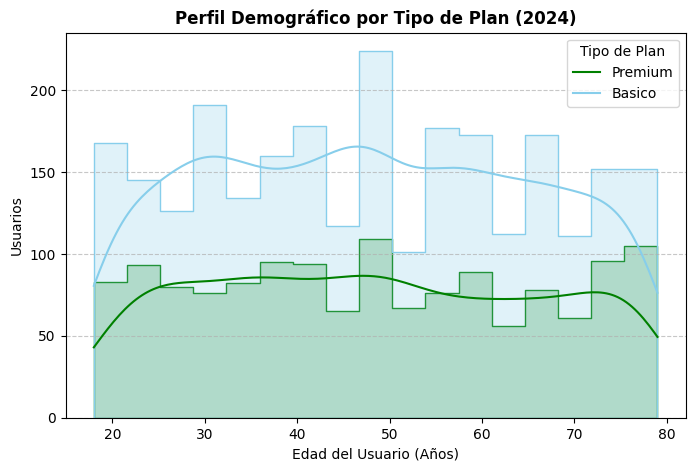

In [31]:
# Histograma para visualizar la edad (age)
plt.figure(figsize=(8, 5))
sns.histplot(
    data=user_profile, #dataframe
    x='age',         # Variable aanalizar
    hue='plan',     # Segmentación por tipo de plan
    palette=['skyblue', 'green'],
    kde=True,       # Línea de densidad
    element='step'  
)

plt.title('Perfil Demográfico por Tipo de Plan (2024)',fontweight='bold')
plt.legend(title='Tipo de Plan', labels=['Premium', 'Basico']) 
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xlabel("Edad del Usuario (Años)")
plt.ylabel('Usuarios')
plt.show()

#### 💡Insights: 
- Encontramos una distribución uniforme. La adopción del servicio es bastante constante desde los 18 hasta los 80 años.
- Se observa claramente que el Plan Básico tiene un volumen significativamente mayor en comparación con el Premium, con un  65.64%  del total.
- Hay un pico notable de usuarios del Plan Básico cerca de los 45-50 años. Podría ser un segmento clave para campañas nuevas.
- El plan premium se observa estable al parecer la propuesta de valor del Premium no depende de la edad.
- El usuario del Plan básico realiza en promedio 4 llamadas y consume 18-20 minutos de mensajes.  No existe una diferencia significativa en los hábitos de consumo entre los usuarios del plan Básico y Premium, tiene un patrón de consumo similar.


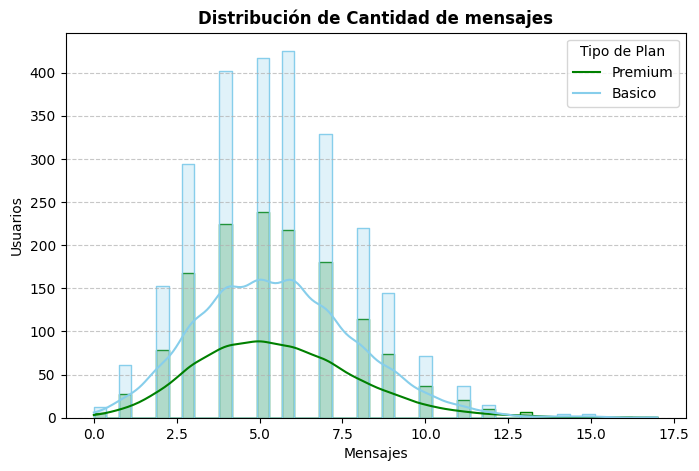

In [32]:
# Histograma para visualizar la cant_mensajes
plt.figure(figsize=(8, 5))
sns.histplot(
    data=user_profile, #dataframe
    x='cant_mensajes',         # Variable aanalizar
    hue='plan',     # Segmentación por tipo de plan
    palette=['skyblue', 'green'],
    kde=True,       # Línea de densidad
    element='step'  # para que las distribuciones no se tapen entre sí
)

plt.title('Distribución de Cantidad de mensajes',fontweight='bold')
plt.legend(title='Tipo de Plan', labels=['Premium', 'Basico']) 
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xlabel('Mensajes')
plt.ylabel('Usuarios')
plt.show()


💡Insights: 
Existe una similitud notable en las curvas de densidad, lo que sugiere que el hábito en el número de mensajes enviados no depende del plan contratado.
Se observa una distribución simétrica, termina de forma natural sin outliers. Es casi una campana.
La tendencia está entre 5 y 6 mensajes.


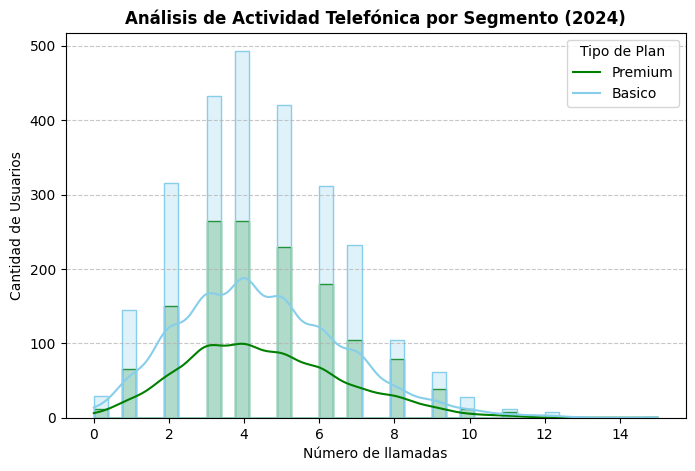

In [33]:
# Histograma para visualizar la cant_llamadas
plt.figure(figsize=(8, 5))
sns.histplot(
    data=user_profile,
    x='cant_llamadas',         
    hue='plan',     
    palette=['skyblue', 'green'],
    kde=True,    
    element='step'  
)

plt.title('Análisis de Actividad Telefónica por Segmento (2024)',fontweight='bold')
plt.legend(title='Tipo de Plan', labels=['Premium', 'Basico']) 
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xlabel('Número de llamadas')
plt.ylabel('Cantidad de Usuarios')
plt.show()


💡Insights: 

Existe una similitud notable en las curvas de densidad, lo que sugiere que el nivel de suscripción no altera el hábito de consumo telefónico de los usuarios.
Distribución: Los datos presentan un ligero sesgo a la derecha, con un rango de actividad que se concentra principalmente entre las 2 y 6 llamadas, con casos aislados que alcanzan hasta 14 llamadas.

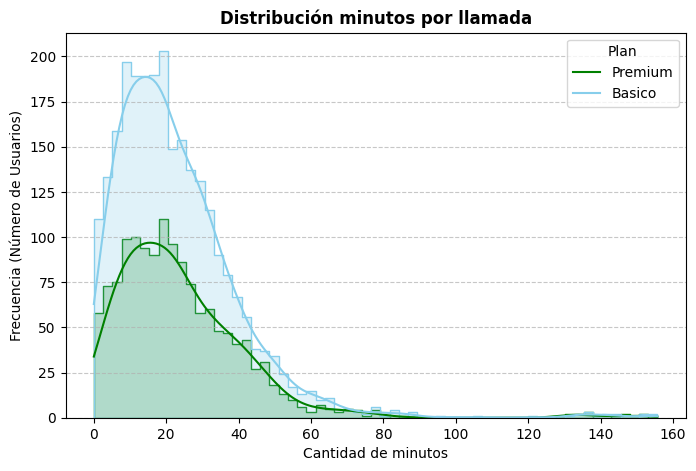

In [34]:
# Histograma para visualizar la cant_minutos_llamada
plt.figure(figsize=(8, 5))
sns.histplot(
    data=user_profile, #dataframe
    x='cant_minutos_llamada',         # Variable aanalizar
    hue='plan',     # Segmentación por tipo de plan
    palette=['skyblue', 'green'],
    kde=True,       # Línea de densidad
    element='step'  # para que las distribuciones no se tapen entre sí
)

plt.title('Distribución minutos por llamada',fontweight='bold')
plt.legend(title='Plan', labels=['Premium', 'Basico']) 
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xlabel('Cantidad de minutos')
plt.ylabel('Frecuencia (Número de Usuarios)')
plt.show()


💡Insights: 
- Ambas distribuciones muestran un sesgo a la derecha (right skewed).
- La mayoría de los usuarios realizan llamadas de entre 10 y 25 minutos y solo algunos más de 80.
- Las curvas de densidad (KDE) de ambos planes tienen formas casi idénticas.
- Existe una caída drástica después de los 40 minutos. Muy pocos usuarios mantienen conversaciones largas. Sin embargo, se observan algunos valores atípicos (outliers) que superan los 120 minutos, lo cual podría representar llamadas de soporte técnico o casos muy específicos de larga distancia.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

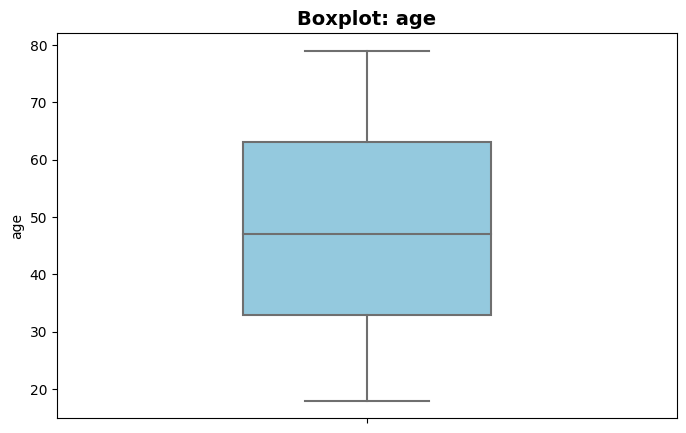

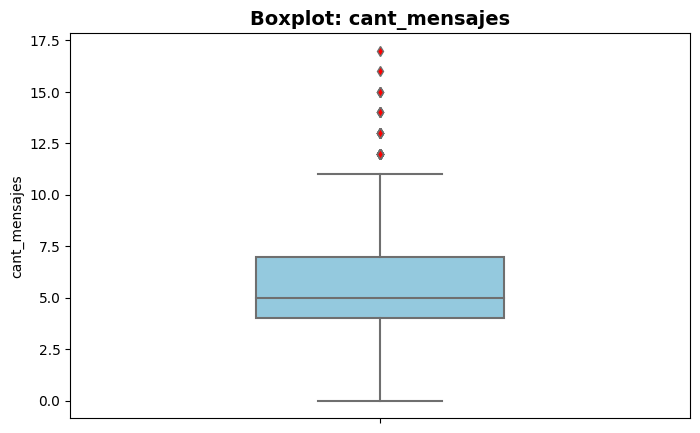

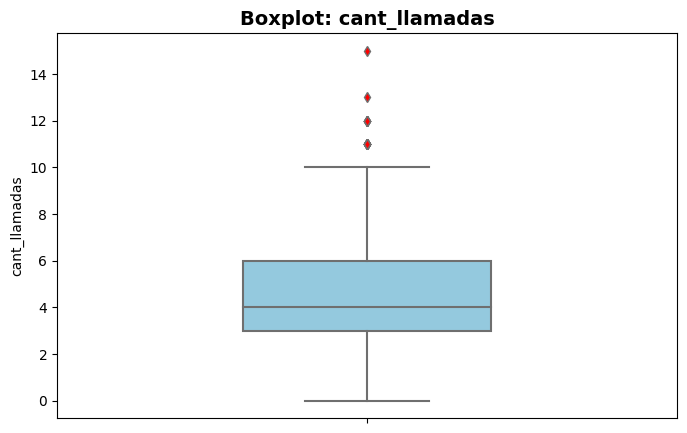

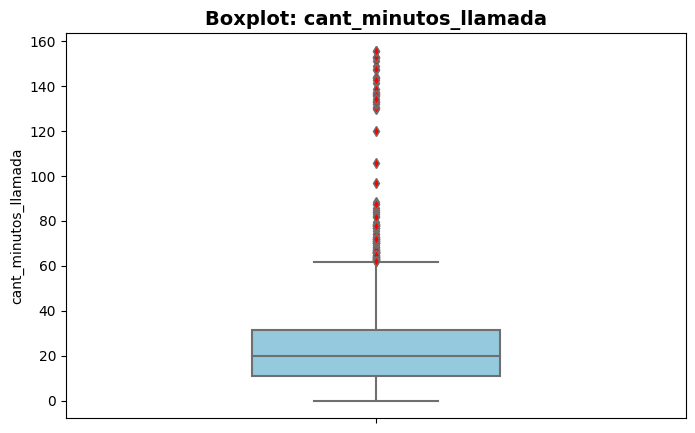

In [35]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
#Boxplot de age
for col in columnas_numericas:
    plt.figure(figsize=(8, 5))
    sns.boxplot(
        y=user_profile[col], 
        color='skyblue',       
        linewidth=1.5,
        width=0.4,  
        flierprops={"markerfacecolor":"red"}
    )
    plt.title(f'Boxplot: {col}',fontsize=14, fontweight='bold')
    plt.show()


💡Insights: 
- Age: No hay outliers, esto confirma que no hay valores atípicos en la edad; todos los usuarios están dentro del rango esperado para este servicio.
- cant_mensajes: Presenta outliers o valores atípicos por arriba de 12, el promedio está en 5 mensajes. 
- cant_llamadas: Se observan outliers por arriba de 10 llamadas, con un promedio de 4.
- cant_minutos_llamada: El  50% de las llamadas dura 20 minutos. Se observa una gran cantidad de outilers que se extienden desde los 62 minutos hasta casi los 160. Esto indica que, aunque la mayoría de las llamadas son cortas, hay un grupo considerable de usuarios que tienen un comportamiento de consumo extremadamente alto. El promedio no representa al cliente típico. Se confirma el sesgo. 

In [36]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
for col in columnas_limites:
    Q1=user_profile[col].quantile(0.25)
    Q3=user_profile[col].quantile(0.75)
    IQR= Q3 - Q1
    
    # Definir límites para outliers
    lower = Q1-1.5 * IQR
    upper =  3 + 1.5 * IQR

    print(f'Límite inferior: {col}', lower)
    print(f'Limite superior: {col}', upper)

Límite inferior: cant_mensajes -0.5
Limite superior: cant_mensajes 7.5
Límite inferior: cant_llamadas -1.5
Limite superior: cant_llamadas 7.5
Límite inferior: cant_minutos_llamada -19.322500000000005
Limite superior: cant_minutos_llamada 33.4425


In [37]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights: 
- cant_mensajes: Mantengo los datos hasta 17.5 para ver el rango completo de comunicación
- cant_llamadas: El límite superior de 7.5 significa que cualquier usuario que realice 8 o más llamadas es considerado un outlier bajo el método IQR.
En la gráfica se ve claramente que hay una cantidad considerable de usuarios en los valores de 8, 9, 10 y hasta 14 llamadas, por lo que se mantendrán los outliers. 
- cant_minutos_llamada: Mantengo los outliers porque puede ser un segmento importante de usuarios que tienen un comportamiento de consumo alto y  debe ser analizado su comportamiento.
Tomo  la decisión estratégica de mantener los outliers, basada en que los registros representan comportamientos reales de 'usuarios intensivos' cuya exclusión resultaría en una pérdida de información crítica para el análisis de rentabilidad.



---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [38]:
# Crear columna grupo_uso
import numpy as np
user_profile['grupo_uso']=np.where((user_profile['cant_llamadas']< 5) & (user_profile['cant_mensajes'] < 5), 'Bajo uso',
    np.where((user_profile['cant_llamadas']< 10) & (user_profile['cant_mensajes'] < 10), 'Uso medio', 'Alto uso'))

In [39]:
# verificar cambios
user_profile.head()

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada,first_name,last_name,age,city,reg_date,plan,churn_date,grupo_uso
0,10000,7,3,23.70,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,Uso medio
1,10001,5,10,33.18,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,Alto uso
2,10002,5,2,10.74,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,Uso medio
3,10003,11,3,8.99,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,Alto uso
4,10004,4,3,8.01,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [40]:
# Crear columna grupo_edad
user_profile['grupo_edad']=np.where((user_profile['age'] < 30), 'Joven',
    np.where((user_profile['age'] >= 30) & (user_profile['age'] < 60), 'Adulto', 'Adulto Mayor'))

In [41]:
# verificar cambios
display(user_profile.head())


,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada,first_name,last_name,age,city,reg_date,plan,churn_date,grupo_uso,grupo_edad
0,10000,7,3,23.70,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,Uso medio,Adulto
1,10001,5,10,33.18,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,Alto uso,Adulto
2,10002,5,2,10.74,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,Uso medio,Adulto
3,10003,11,3,8.99,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,Alto uso,Adulto Mayor
4,10004,4,3,8.01,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

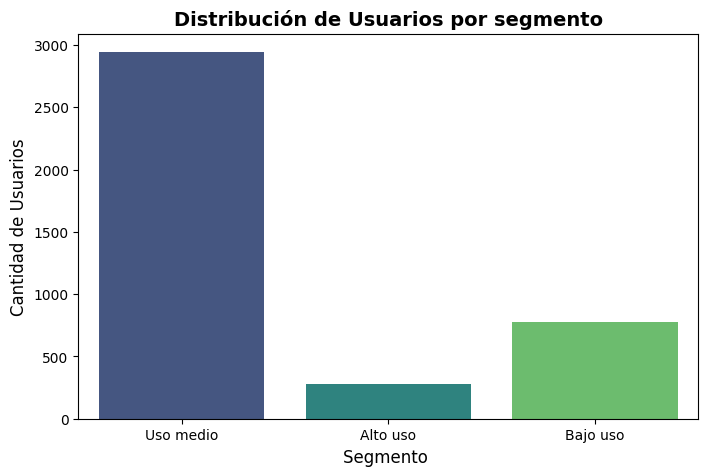

In [42]:
# Visualización de los segmentos por uso
plt.figure(figsize=(8, 5))

# Generar el gráfico de conteo
ax=sns.countplot(data=user_profile, x='grupo_uso', palette='viridis')


# Personalización profesional (como lo hemos estado haciendo)
plt.title('Distribución de Usuarios por segmento', fontsize=14, fontweight='bold')
plt.xlabel('Segmento ', fontsize=12)
plt.ylabel('Cantidad de Usuarios', fontsize=12)

plt.show()

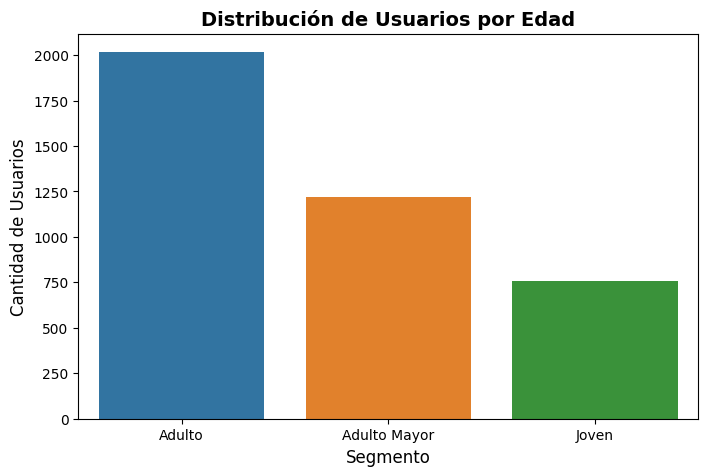

In [43]:
# Visualización de los segmentos por edad
plt.figure(figsize=(8, 5))

# Generar el gráfico de conteo
sns.countplot(data=user_profile, x='grupo_edad')

# Personalización profesional (como lo hemos estado haciendo)
plt.title('Distribución de Usuarios por Edad', fontsize=14, fontweight='bold')
plt.xlabel('Segmento', fontsize=12)
plt.ylabel('Cantidad de Usuarios', fontsize=12)

plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- Se detectaron datos nulos y centinelas en diferentes columnas 

•	El 11.72% del total de **city** eran datos nulos y  96 registros tenían el centinela ‘?’<br> 
•	Encontré que  **date**, tiene nulos pero con un porcentaje muy bajo del  0.12%, solo  50 registros.<br> 
•	**duration**  con 22076 registros, que representan el  55.19%  eran valores nulos. <br> 
•	**length** con un 44% también es un dato valioso para el análisis, por lo que es importante su revisión para decidir su imputación. No será eliminado.<br> 
•	**churn_date**, tenía un valor alto del 88.35% , valor esperado ya que corresponde a la fecha de cancelación de la suscripción.<br> 
•	Identifique  55 valores centinel  -999 en **age**.<br> 

🔍 **Segmentos por Edad**<br> 
El segmento  *Adulto* (30 a 59 años) domina el mercado, es el más valioso por volumen con más de 2000 usuarios.Este grupo representa el núcleo de tu base de clientes.<br> 
*Adulto Mayor* (60+ años): Es el segundo grupo en importancia, con poco más de 1,250 usuarios<br> 
*Joven* (menores de 30 años): Es el segmento más pequeño, con aproximadamente 750 usuarios.

📊 **Segmentos por Nivel de Uso**<br> 
El segmento *Adulto* es el que más contribuye al volumen del *Uso Medio*, consolidándose como el perfil de cliente estándar.<br> 
A pesar de la diferencia de edad entre *Adultos* y *Adultos Mayore*s, ambos tienden a concentrarse en el nivel de *Uso Medio*, lo que sugiere que la edad no es un factor que dispare el consumo hacia el nivel "Alto" de forma agresiva.<br> 

El *Alto Uso* es un comportamiento excepcional en todos los rangos de edad, representando la menor proporción de la muestra total. Aunque es pequeño, con menos de 500 usuarios, son los  clientes que superan las 10 llamadas o mensajes, lo que indica una alta dependencia del servicio.<br> 

➡️ <br> 
Esto sugiere que, el uso extremo no parece ser exclusivo de una sola edad, sino que actúa como un comportamiento distribuido de forma minoritaria.
*Alto* es un segmento que representa una oportunidad para migrarlos a planes de gama alta .<br> 
Los outliers identificados podrían representar pequeños emprendedores o trabajadores independientes con consumos mayores.<br> 
También es importante considerar que el aumento en el número de usuarios que generan estos oultiers,  podría  comprometer la  capacidad técnica de la empresa y afectar la estabilidad de los usuarios de *Uso medio*.<br> 

💡 **Recomendaciones**<br> 
a)	Identificar a los usuarios del segmento de *Alto uso* que actualmente tienen planes básicos y ofréceles una actualización a un plan Premium para generar un mayor ingreso promedio por usuario.<br> 
b) Dado que los usuarios del segmento *Adulto Mayor* son el segundo grupo más grande, se podrían diseñar planes con beneficios específicos como redes sociales ilimitadas, para asegurar su lealtad<br> 
c) Dirigir campañas publicitarias al segmento *Adulto* que es el de mayor volumen.<br> 
d) ConnectaTel podría lanzar promociones enfocadas en datos móviles al segmento *Joven* que es el de menor volumen.<br> 
e) Investigar si hay usuarios del segmento *Alto uso* que utilizan su línea personal para fines profesionales, lo que abre la puerta para crear productos específicos para microempresas.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`